In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

In [2]:
import glob

In [3]:
path_to_files = '/mnt/g/My Drive/structure-loss-classification/logdir/incremental_training/LitLeNet5/only_bad/lightning_logs/*'

In [4]:
dfs = []

In [5]:
for folder in glob.glob(path_to_files):
    df=pd.read_csv(f'{folder}/metrics.csv')
    dfs.append(df)

In [6]:
len(dfs)

20

In [7]:
import random
import matplotlib.colors as mcolors

def random_colors(n, random_state=None):
    # Set the random seed for reproducibility
    random.seed(random_state)
    
    # Get a list of all base colors supported by matplotlib
    all_colors = list(mcolors.TABLEAU_COLORS) + list(mcolors.CSS4_COLORS)
    
    # Ensure the number of requested colors does not exceed the available colors
    if n > len(all_colors):
        raise ValueError("Requested more colors than are available.")
    
    # Randomly select 'n' unique colors
    selected_colors = random.sample(all_colors, n)
    
    return selected_colors

In [8]:
# Example usage:
colors = random_colors(len(dfs), random_state=42)
print(colors)

['cornsilk', 'tab:pink', 'indigo', 'goldenrod', 'forestgreen', 'darkgreen', 'coral', 'silver', 'burlywood', 'turquoise', 'mistyrose', 'tab:olive', 'tab:gray', 'cadetblue', 'firebrick', 'gainsboro', 'rebeccapurple', 'white', 'slategrey', 'deeppink']


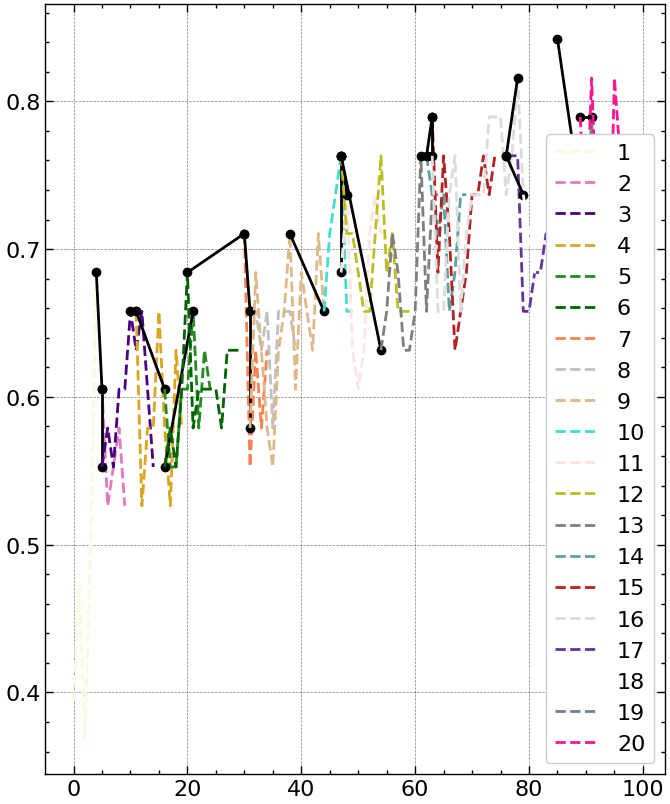

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,10))
# Assuming 'dfs' is a list of dataframes and each dataframe has 'epoch' and 'val_accuracy' columns
for c, df in enumerate(dfs):
    # Plot the main line with markers
    plt.plot(df.epoch, df.val_accuracy, '--', c=colors[c], label=str(c+1))

    # Find the index of the maximum val_accuracy in the current dataframe
    max_val_acc_index = df.val_accuracy.idxmax()

    # If this is not the last dataframe, draw a dotted line to the first point of the next dataframe
    if c < len(dfs) - 1:
        next_df = dfs[c + 1]
        # Get the point with max val_accuracy from the current dataframe and the first point of the next dataframe
        x_values = [df.epoch.iloc[max_val_acc_index], next_df.epoch.iloc[0]]
        y_values = [df.val_accuracy.iloc[max_val_acc_index], next_df.val_accuracy.iloc[0]]
        # Plot with dotted lines
        plt.plot(x_values, y_values, 'o-', color='black')

plt.legend()
plt.show()


In [10]:
#TODO 
# make pipeline_3 notebook
# change increment epochs to 10
# colors from mcolors.TABLEAU_COLORS

In [11]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

import scienceplots
plt.style.use(["science", "notebook", "grid"])
import matplotlib.colors as mcolors

In [12]:
def get_path(model: str, mode: str):
    save_dir = '/mnt/g/My Drive/structure-loss-classification/logdir/pipeline_3'
    out = f'{save_dir}/{model}/{mode}/cv/lightning_logs/*'
    
    return out

In [13]:
from typing import Optional

In [14]:
def plot_metrics(dfs: list, model: str, classification_mode: str, y_lim: Optional[float], save: bool=False):
    
# Assuming 'dfs' is a list of dataframes and each dataframe has 'epoch' and 'val_accuracy' columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    for c, df in enumerate(dfs):
        # Plot the main line with markers
        ax2.plot(df.epoch, df.val_accuracy, '-o',
                            color=list(mcolors.TABLEAU_COLORS.values())[c],
                            label=f'round {str(c+1)}')
        
        ax1.plot(df.epoch, df.val_loss, '-o',
                            color=list(mcolors.TABLEAU_COLORS.values())[c],
                        )


    ax2.legend(loc=(1.005, 0.15))
    ax1.set_title('validation loss')
    ax2.set_title('validation accuracy')
    ax1.set_xlabel('Epoch')
    ax2.set_xlabel('Epoch')
    
    ax1.set_ylim(0, y_lim)
    
    if save:
        plt.savefig(f'results/pipeline_3/{model}-{classification_mode}.pdf', bbox_inches='tight')
    plt.show()


In [15]:
modes = ['binary',
         'only_bad',
         'all'
         ]

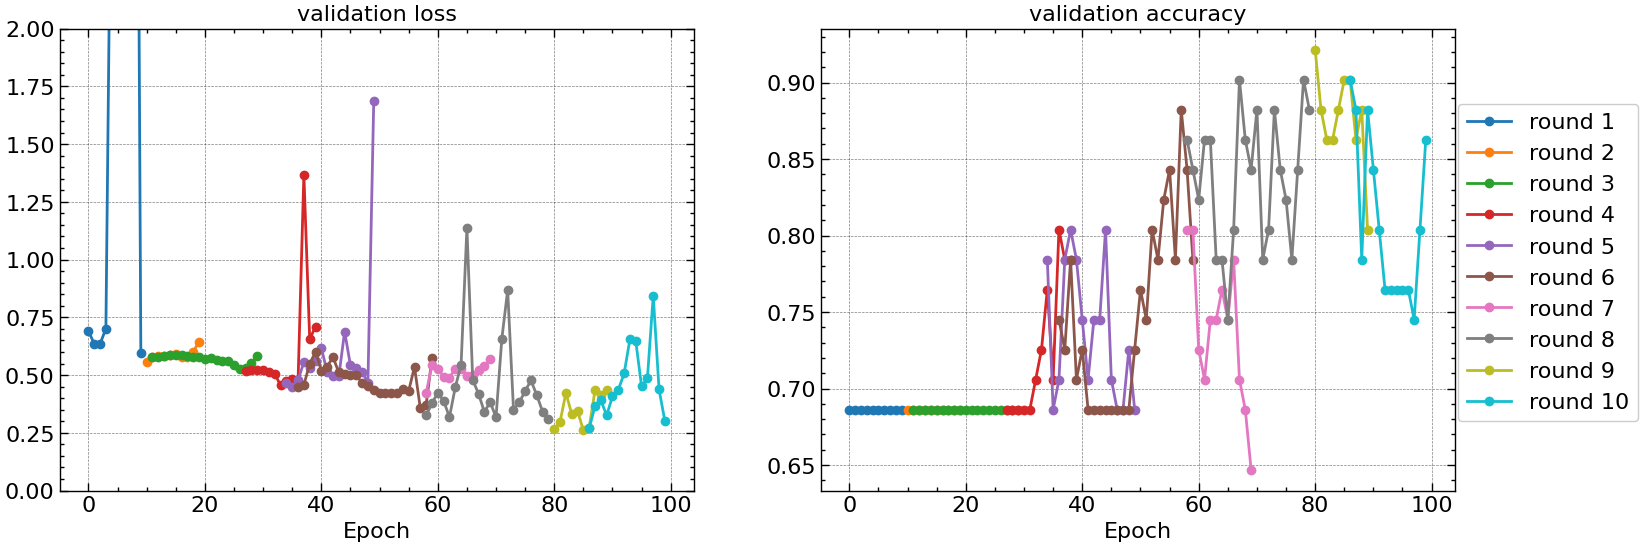

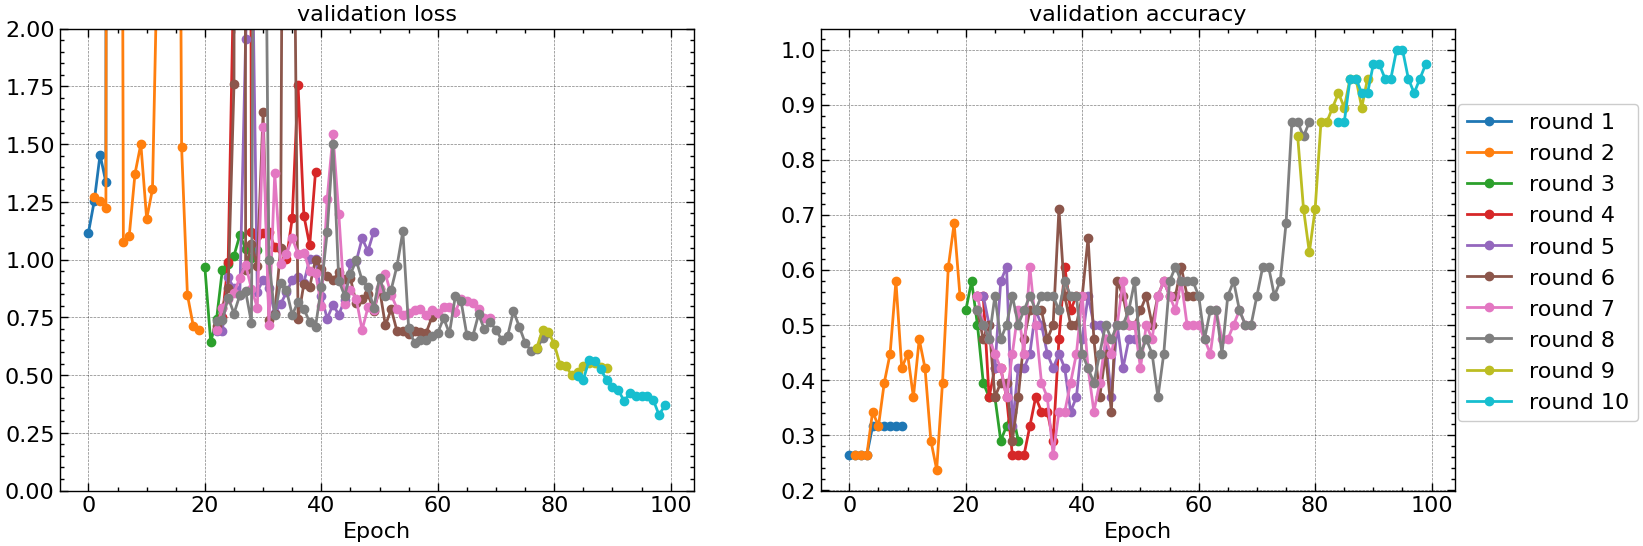

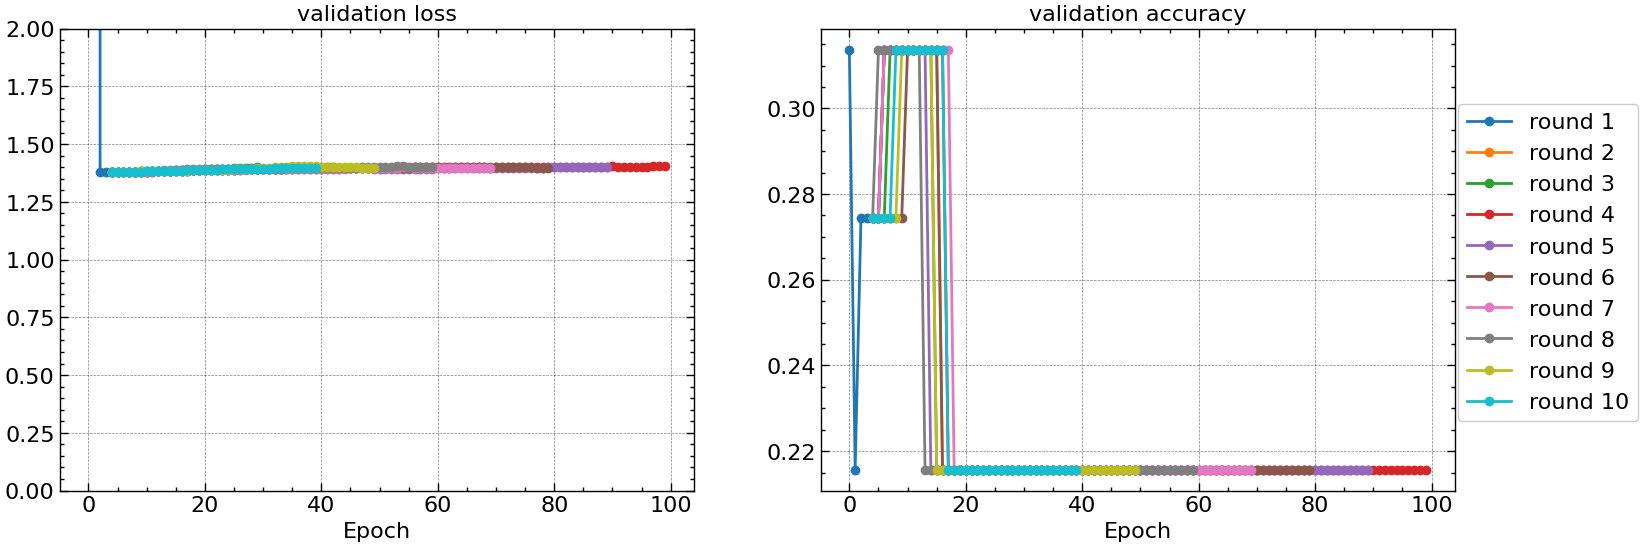

In [16]:
for mode in modes:
    folder_path = get_path('LitVGG16', mode)
    dfs = []
    
    for f in glob.glob(folder_path):
        df=pd.read_csv(f'{f}/metrics.csv')
        dfs.append(df)
        
    plot_metrics(dfs=dfs, model='LitVGG16', classification_mode=mode, y_lim=2, save=True)
    

In [17]:
h = 'ello'